In [ ]:
from pathlib import Path
from vdmtools.io import hd5_to_pandas

import os
import shutil
import tables
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
file = "9639_240516203939_240516222543.hd5"
output_dir = Path("./data/2024vdm_2DScans")


In [21]:
fill = int(file.split("_")[0])
path = Path(f"/brildata/vdmdata24/{fill}/{file}")
copied_file = output_dir / file


### Copy file to wd

In [23]:
output_dir.mkdir(parents=True, exist_ok=True)
shutil.copy2(path, copied_file)
print(f"Copied input file to: {copied_file}")


0

### Get description from original file

In [24]:
t = tables.open_file(path.as_posix(), "r")
desc = t.get_node("/vdmscan").description._v_colobjects.copy()
t.close()

### Remove vdmscan from copied file

In [25]:
with tables.open_file(copied_file.as_posix(), "a") as t:
    t.remove_node("/vdmscan")


<h1>Pair all scans</h1>

<h2>Modify pair_index, from 0 to 16 with +2 step</h2>

SEPARATION cycles: 19
CROSSING main cycle length: 196


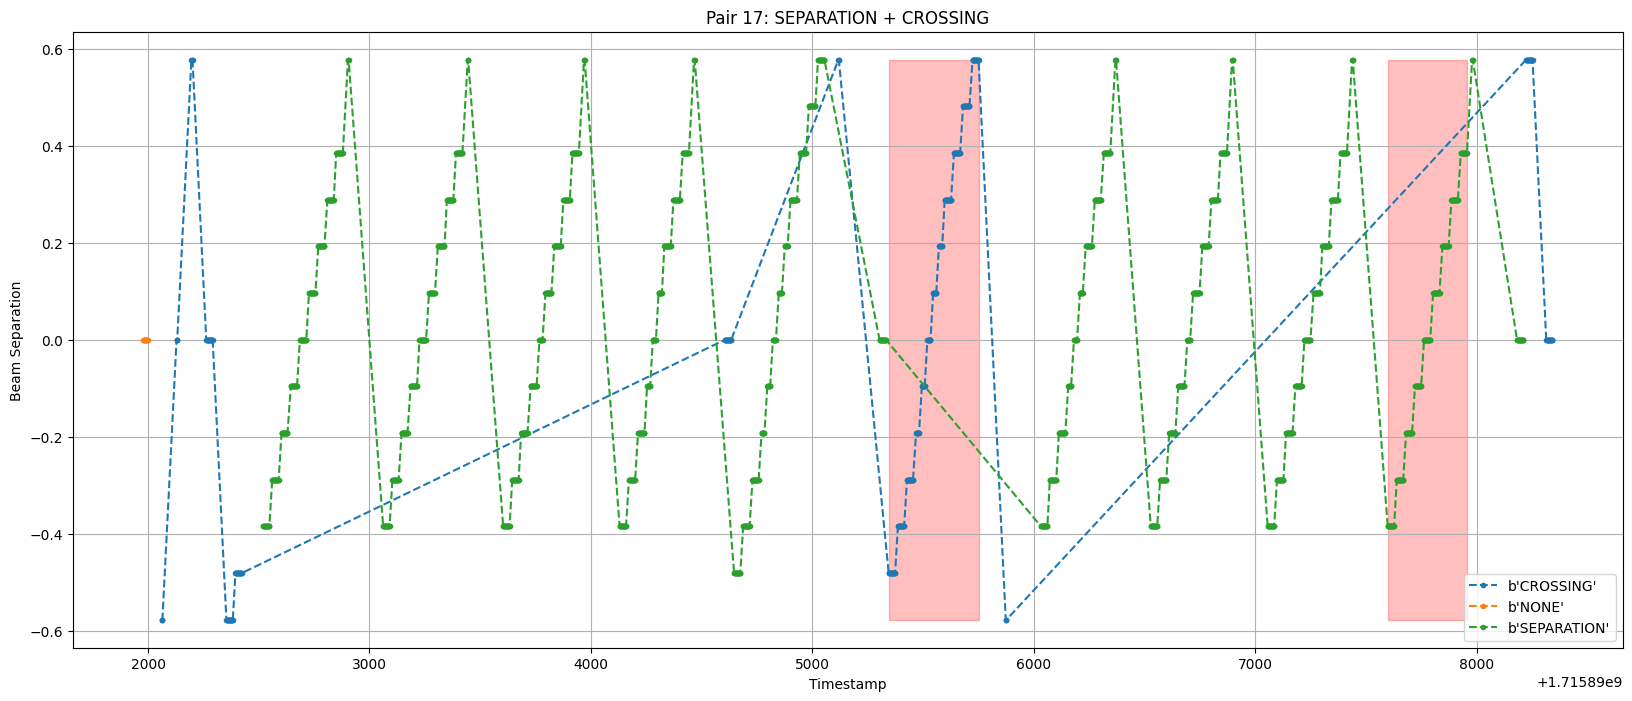

In [ ]:
def split_into_cycles(df_group, gap=20):
    ts = df_group["timestampsec"].values
    gaps = np.where(np.diff(ts) > gap)[0]

    cycles = []
    start = 0
    for g in gaps:
        cycles.append(df_group.iloc[start:g+1])
        start = g+1
    cycles.append(df_group.iloc[start:])
    return cycles


df = hd5_to_pandas(path, "vdmscan")
sep = df[df["nominal_sep_plane"] == b"SEPARATION"].sort_values("timestampsec")
cross = df[df["nominal_sep_plane"] == b"CROSSING"].sort_values("timestampsec")

sep_cycles = split_into_cycles(sep)
cross_cycles_raw = split_into_cycles(cross)
cross_main = max(cross_cycles_raw, key=lambda c: len(c))

print("SEPARATION cycles:", len(sep_cycles))
print("CROSSING main cycle length:", len(cross_main))

pair_index = 16  # use an even number: 0, 2, 4, 6, 8, 10, 12, 14, 16

if pair_index % 2 != 0:
    raise ValueError("pair_index must be an even number.")

if not 0 <= pair_index < len(sep_cycles):
    raise IndexError(f"pair_index={pair_index} is out of range for {len(sep_cycles)} SEPARATION cycles.")

sc = sep_cycles[pair_index]
cc = cross_main

fig = plt.figure(figsize=(20, 8))
ax = plt.subplot()

for plane, group in df.groupby("nominal_sep_plane"):
    ax.plot(group["timestampsec"], group["sep"], "--o", label=str(plane), markersize=3)

ymin, ymax = df["sep"].min(), df["sep"].max()

ax.fill_betweenx(
    [ymin, ymax],
    sc["timestampsec"].min(),
    sc["timestampsec"].max(),
    color="red",
    alpha=0.25,
)

ax.fill_betweenx(
    [ymin, ymax],
    cc["timestampsec"].min(),
    cc["timestampsec"].max(),
    color="red",
    alpha=0.25,
)

ax.set_title(f"Pair {pair_index // 2 + 1}: SEPARATION + CROSSING")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Beam Separation")
ax.grid(True)

handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(), loc="lower right")

plt.show()


In [ ]:
def match_crossing_by_sep(sc, cc):
    sc = sc.copy()
    cc = cc.copy()

    ss = sc["sep"].unique()
    cc = cc[cc["sep"].isin(ss)]

    return cc


def make_pair_df(sc, cc):
    sc = sc.copy().reset_index(drop=True)
    cc_matched = match_crossing_by_sep(sc, cc)

    sc["nominal_sep_plane"] = b"SEPARATION"
    cc_matched["nominal_sep_plane"] = b"CROSSING"

    df_out = pd.concat([sc, cc_matched], ignore_index=True)
    df_out = df_out.sort_values("timestampsec").reset_index(drop=True)

    return df_out


sc = sep_cycles[pair_index]
cc = cross_main
save_idx = pair_index // 2 + 1

df_out = make_pair_df(sc, cc)

print(df_out)


     fillnum  runnum  lsnum  nbnum  timestampsec  timestampmsec  totsize  \
0       9639  380847    711     40    1715895387            514      330   
1       9639  380847    711     44    1715895389             39      330   
2       9639  380847    711     48    1715895390            501      330   
3       9639  380847    711     52    1715895391            925      330   
4       9639  380847    711     56    1715895393            345      330   
..       ...     ...    ...    ...           ...            ...      ...   
302     9639  380847    821     40    1715897951            755      330   
303     9639  380847    821     44    1715897953            196      330   
304     9639  380847    821     48    1715897954            621      330   
305     9639  380847    821     52    1715897956            162      330   
306     9639  380847    821     56    1715897957            580      330   

     publishnnb  datasourceid  algoid  ...  5ldoros_b2herr  5ldoros_b2verr  \
0        

In [58]:
tables.file._open_files.close_all()
clean_file = file.replace(".hd5", "")
output_path = output_dir / f"{clean_file}_{save_idx}.hd5"


In [59]:
orig_file = copied_file
clean_file = file.replace(".hd5", "")
output_path = output_dir / f"{clean_file}_{save_idx}.hd5"

shutil.copy2(orig_file, output_path)
print("Copied:", output_path)


Copied: data/2024vdm_2DScans/9639_240516203939_240516222543_9.hd5


In [60]:
tables.file._open_files.close_all()

with tables.open_file(output_path, "a") as f:

    if "/vdmscan" in f:
        f.remove_node("/", "vdmscan")

    table = f.create_table("/", "vdmscan", desc)
    table.append(df_out.to_records(index=False).tolist())
    table.flush()

print("Saved updated vdmscan to:", output_path)


Saved updated vdmscan to: data/2024vdm_2DScans/9639_240516203939_240516222543_9.hd5


/nfshome0/lumipro/brilconda-3.2.16/lib/python3.7/site-packages/tables/path.py:155: NaturalNameWarning: object name is not a valid Python identifier: '5ldoros_b1names'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/nfshome0/lumipro/brilconda-3.2.16/lib/python3.7/site-packages/tables/path.py:155: NaturalNameWarning: object name is not a valid Python identifier: '5ldoros_b1hpos'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/nfshome0/lumipro/brilconda-3.2.16/lib/python3.7/site-packages/tables/path.py:155: NaturalNameWarning: object name is not a valid Python identifier: '5ldoros_b1vpos'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural nami